# Task 1: Binary Classification — High vs. Low Pollution Facility

**Project:** Emissions from Above: Classifying Power Plant Pollution Levels via Satellite Imagery  
**Dataset:** US Power Plant Satellite Imagery Dataset (USPPDS) + EPA eGRID 2014

---

## Overview

Train a CNN (ResNet or EfficientNet backbone) on satellite image patches centered on power plant coordinates.  
Labels are derived from EPA eGRID emissions intensity thresholds — **top quartile vs. bottom quartile of CO₂ per MWh**.

> **Goal:** Predict whether a facility is *high-pollution* or *low-pollution* from its Landsat 8 satellite image patch.


## 1. Imports & Environment Setup

In [1]:
# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Geospatial / imagery
import rasterio
from rasterio.plot import show as rshow

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models
from torch.optim.lr_scheduler import CosineAnnealingLR

# Sklearn utilities
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

# Optional: Grad-CAM
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    GRADCAM_AVAILABLE = True
except ImportError:
    GRADCAM_AVAILABLE = False
    print("pytorch-grad-cam not installed. Run: pip install grad-cam")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


pytorch-grad-cam not installed. Run: pip install grad-cam
Using device: cuda


## 2. Configuration & Paths

In [2]:
import sys
import os
import time
from google.colab import drive


drive.mount('/content/drive')

sys.path.append('/content/drive/My Drive/machine-learning-II/ML2FP')


# ── EDIT THESE PATHS TO MATCH YOUR LOCAL SETUP ─────────────────────────────
DATA_ROOT     =  Path("/content/drive/My Drive/machine-learning-II/ML2FP/data")                          # project root
LANDSAT_DIR   = DATA_ROOT / "uspp_landsat"            # .tif image patches
EGRID_XLSX    = DATA_ROOT / "eGRID2014_Data_v2_US_EPA_with_imagery_list_for_power_plants.xlsx"
OUTPUT_DIR    = Path("outputs/task1_binary_clf")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Model / training hyper-parameters
IMG_SIZE      = 75    # Landsat patches are ~75×75 pixels
BATCH_SIZE    = 32
NUM_EPOCHS    = 30
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
DROPOUT_RATE  = 0.3
N_FOLDS       = 5    # for cross-validation

# Emissions threshold strategy
# "quartile" uses top/bottom 25% of CO2_lbs_per_MWh; "median" splits at 50th percentile
THRESHOLD_STRATEGY = "quartile"   # or "median"



Mounted at /content/drive


## 3. Load & Explore the eGRID Metadata

In [3]:
# eGRID data lives in the 'PLNT14' sheet
egrid_raw = pd.read_excel(EGRID_XLSX, sheet_name="PLNT14", header=1)
print(f"Raw shape: {egrid_raw.shape}")
egrid_raw.head(3)


Raw shape: (8503, 121)


,SEQPLT14,Imagery Status,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,BANAME,...,PLWIPR,PLSOPR,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTHPR,PLCYPR,PLCNPR
0,1,NO,AK,Agrium Kenai Nitrogen Operations,54452,Homer Electric Assn Inc,19558.0,Agrium US Inc,179,Alaska Miscellaneous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NO,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221.0,"Alaska Village Elec Coop, Inc",221,Alaska Miscellaneous,...,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0
2,3,NO,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329.0,"Copper Valley Elec Assn, Inc",4329,Alaska Miscellaneous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Key columns we need
# SEQPLT14  - sequential plant number (eGrid ID used in filenames)
# PLFUELCT  - primary fuel category
# PLCO2AN   - annual CO2 emissions (tons/yr)
# PLNGENAN  - annual net generation (MWh)
# Imagery Status - whether imagery exists for this plant

relevant_cols = [
    'SEQPLT14', 'PNAME', 'PSTATABB', 'CNTYNAME',
    'PLFUELCT', 'PLPRMFL',
    'PLCO2AN',   # Annual CO2 (tons)
    'PLNGENAN',  # Annual net generation (MWh)
    'PLCO2RTA',  # CO2 rate (lbs/MWh) — primary label source
    'CAPFAC',    # Capacity factor
    'NAMEPCAP',  # Nameplate capacity (MW)
    'LAT', 'LON',
]

# Some column names vary by eGRID version — select what exists
available = [c for c in relevant_cols if c in egrid_raw.columns]
egrid = egrid_raw[available].copy()

# Add imagery status if the column exists
img_col = [c for c in egrid_raw.columns if 'imagery' in c.lower() or 'status' in c.lower()]
if img_col:
    egrid['imagery_status'] = egrid_raw[img_col[0]]
    egrid = egrid[egrid['imagery_status'].notna()]

print(f"Filtered shape: {egrid.shape}")
egrid.head()


Filtered shape: (8503, 14)


,SEQPLT14,PNAME,PSTATABB,CNTYNAME,PLFUELCT,PLPRMFL,PLCO2AN,PLNGENAN,PLCO2RTA,CAPFAC,NAMEPCAP,LAT,LON,imagery_status
0,1,Agrium Kenai Nitrogen Operations,AK,Kenai Peninsula,GAS,NG,NaN,NaN,NaN,NaN,21.6,60.673200,-151.378400,NO
1,2,Alakanuk,AK,WADE HAMPTON,OIL,JF,1829.492,2244.001,1630.563,0.099,2.6,62.683300,-164.654400,NO
2,3,Allison Creek Hydro,AK,Valdez Cordova,HYDRO,WAT,NaN,NaN,NaN,NaN,6.5,61.084444,-146.353333,NO
3,4,Anchorage 1,AK,Anchorage,GAS,NG,25311.097,33641.999,1504.732,0.032,121.4,61.222100,-149.866100,NO
4,5,Angoon,AK,Hoonah-Angoon,OIL,DFO,1494.348,1692.999,1765.327,0.102,1.9,57.447778,-134.492778,NO


In [5]:
# ── Emissions intensity: CO2 rate (lbs / MWh) ───────────────────────────────
CO2_COL = 'PLCO2RTA' if 'PLCO2RTA' in egrid.columns else None

if CO2_COL is None:
    # Compute from raw totals if rate column is absent
    egrid['co2_intensity'] = (egrid['PLCO2AN'] * 2000) / egrid['PLNGENAN'].replace(0, np.nan)
    CO2_COL = 'co2_intensity'

egrid = egrid.rename(columns={CO2_COL: 'co2_intensity'})
egrid['co2_intensity'] = pd.to_numeric(egrid['co2_intensity'], errors='coerce')

# Drop rows without intensity data or image
egrid = egrid.dropna(subset=['co2_intensity', 'SEQPLT14'])
egrid['SEQPLT14'] = egrid['SEQPLT14'].astype(int)

print(f"Plants with valid CO2 intensity: {len(egrid)}")
egrid['co2_intensity'].describe()


Plants with valid CO2 intensity: 6721


,co2_intensity
count,6721.000000
mean,1132.319119
std,13779.184264
min,0.000000
25%,0.000000
50%,0.000000
75%,1253.767000
max,873696.999000


In [6]:
# ── Assign binary labels ─────────────────────────────────────────────────────
if THRESHOLD_STRATEGY == "quartile":
    q_low  = egrid['co2_intensity'].quantile(0.25)
    q_high = egrid['co2_intensity'].quantile(0.75)
    # Keep only top and bottom quartile plants (cleaner signal)
    egrid = egrid[(egrid['co2_intensity'] <= q_low) | (egrid['co2_intensity'] >= q_high)].copy()
    egrid['label'] = (egrid['co2_intensity'] >= q_high).astype(int)   # 1 = high pollution
    print(f"  Low threshold  (Q25): {q_low:.1f} lbs/MWh")
    print(f"  High threshold (Q75): {q_high:.1f} lbs/MWh")
else:  # median split
    med = egrid['co2_intensity'].median()
    egrid['label'] = (egrid['co2_intensity'] >= med).astype(int)
    print(f"  Median threshold: {med:.1f} lbs/MWh")

print(f"\nLabel distribution:\n{egrid['label'].value_counts()}")
print(f"  0 = low pollution | 1 = high pollution")


  Low threshold  (Q25): 0.0 lbs/MWh
  High threshold (Q75): 1253.8 lbs/MWh

Label distribution:
label
0    3770
1    1681
Name: count, dtype: int64
  0 = low pollution | 1 = high pollution


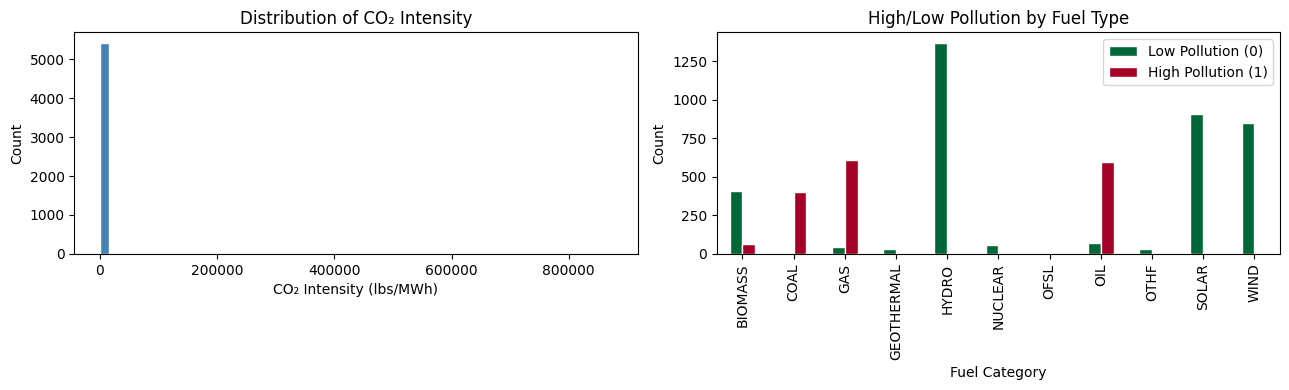

In [7]:
# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(egrid['co2_intensity'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_xlabel('CO₂ Intensity (lbs/MWh)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of CO₂ Intensity')

fuel_counts = egrid.groupby(['PLFUELCT','label']).size().unstack(fill_value=0)
fuel_counts.plot(kind='bar', ax=axes[1], colormap='RdYlGn_r', edgecolor='white')
axes[1].set_xlabel('Fuel Category')
axes[1].set_ylabel('Count')
axes[1].set_title('High/Low Pollution by Fuel Type')
axes[1].legend(['Low Pollution (0)', 'High Pollution (1)'])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_overview.png', dpi=150)
plt.show()


## 4. Build Image Paths & Verify

In [9]:
def build_landsat_path(row, base_dir: Path) -> Path:
    """Reconstruct the Landsat filename from eGRID metadata.
    Filename convention: ls8_{SEQPLT14}_{PSTATABB}_{PLFUELCT}.tif
    """
    egrid_id   = int(row['SEQPLT14'])
    state      = str(row.get('PSTATABB', 'XX')).strip().upper()
    fuel       = str(row.get('PLPRMFL', 'UNKN')).strip().upper()
    fname      = f"ls8_{egrid_id}_{state}_{fuel}.tif"
    return base_dir / fname

egrid['img_path'] = egrid.apply(build_landsat_path, axis=1, base_dir=LANDSAT_DIR)
egrid['img_exists'] = egrid['img_path'].apply(lambda p: p.exists())

print(f"Images found: {egrid['img_exists'].sum()} / {len(egrid)}")
egrid_with_img = egrid[egrid['img_exists']].reset_index(drop=True)
print(f"Dataset size after image filtering: {len(egrid_with_img)}")


Images found: 2947 / 5451
Dataset size after image filtering: 2947


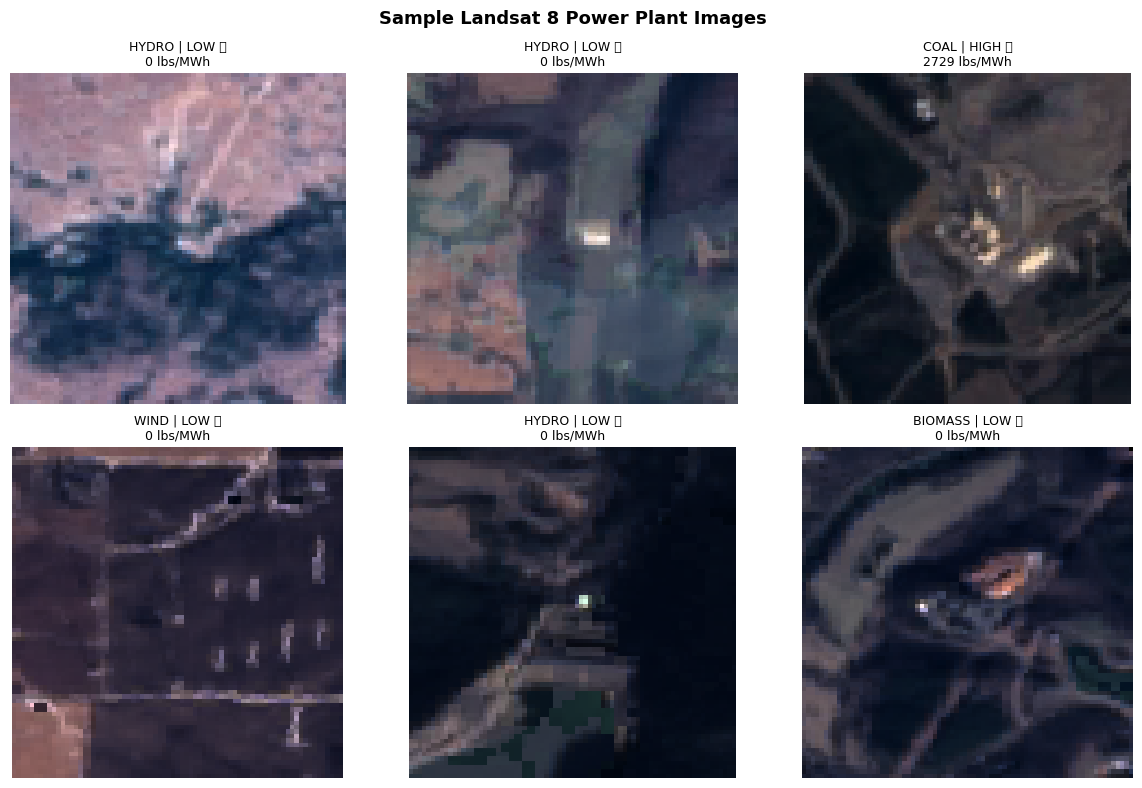

In [10]:
# ── Quick sanity check: display a few images ──────────────────────────────
sample = egrid_with_img.sample(min(6, len(egrid_with_img)), random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for i, (_, row) in enumerate(sample.iterrows()):
    try:
        with rasterio.open(row['img_path']) as src:
            # Use first 3 bands (RGB) and normalise
            img = src.read([1, 2, 3]).transpose(1, 2, 0)
            img = np.clip(img / img.max(), 0, 1)
        axes[i].imshow(img)
        label_str = 'HIGH 🔴' if row['label'] == 1 else 'LOW 🟢'
        axes[i].set_title(f"{row.get('PLFUELCT','?')} | {label_str}\n{row['co2_intensity']:.0f} lbs/MWh", fontsize=9)
        axes[i].axis('off')
    except Exception as e:
        axes[i].set_title(f"Error: {e}"); axes[i].axis('off')
plt.suptitle("Sample Landsat 8 Power Plant Images", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.png', dpi=150)
plt.show()


## 5. PyTorch Dataset & Transforms

In [11]:
class PowerPlantDataset(Dataset):
    """Landsat 8 power plant image dataset for binary pollution classification."""

    def __init__(self, df: pd.DataFrame, transform=None, n_bands: int = 3):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.n_bands   = n_bands   # How many Landsat bands to use (up to 7 available)

    def __len__(self):
        return len(self.df)

    def _load_image(self, path: Path) -> np.ndarray:
        with rasterio.open(path) as src:
            bands = src.read()   # (C, H, W)
        # Select bands, normalise per-channel to [0, 1]
        bands = bands[:self.n_bands].astype(np.float32)
        for c in range(bands.shape[0]):
            ch = bands[c]
            mn, mx = ch.min(), ch.max()
            bands[c] = (ch - mn) / (mx - mn + 1e-8)
        return bands   # (n_bands, H, W)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = self._load_image(row['img_path'])          # numpy (C, H, W)
        img_t  = torch.from_numpy(img)                      # tensor
        label  = torch.tensor(row['label'], dtype=torch.long)

        if self.transform:
            # torchvision transforms expect (C, H, W) float tensors
            img_t = self.transform(img_t)

        return img_t, label


# ── Transforms ──────────────────────────────────────────────────────────────
# Landsat patches are small (~75×75); we resize to 64×64 for CNN compatibility
train_transform = T.Compose([
    T.Resize((64, 64), antialias=True),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
])

val_transform = T.Compose([
    T.Resize((64, 64), antialias=True),
])

print("Dataset and transforms defined.")


Dataset and transforms defined.


## 6. Train / Val / Test Split

In [12]:
# Stratified split to preserve class balance across splits
df = egrid_with_img.copy()

train_val_df, test_df = train_test_split(
    df, test_size=0.15, stratify=df['label'], random_state=SEED
)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.15, stratify=train_val_df['label'], random_state=SEED
)

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")
print(f"Train label balance: {train_df['label'].mean():.2%} high-pollution")

# Weighted sampler to handle class imbalance
class_counts = train_df['label'].value_counts().sort_index().values
sample_weights = [1.0 / class_counts[l] for l in train_df['label']]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_ds = PowerPlantDataset(train_df, transform=train_transform)
val_ds   = PowerPlantDataset(val_df,   transform=val_transform)
test_ds  = PowerPlantDataset(test_df,  transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2)


Train : 2128 | Val : 376 | Test : 443
Train label balance: 31.53% high-pollution


## 7. Model: ResNet-18 with Adapted Input & Head

In [13]:
def build_model(n_input_channels: int = 3, n_classes: int = 2,
                backbone: str = 'resnet18', dropout: float = 0.3) -> nn.Module:
    """
    Load a pretrained ImageNet backbone and adapt:
      - First conv layer for n_input_channels (Landsat has up to 7 bands)
      - Final FC layer for n_classes
    """
    if backbone == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    elif backbone == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    elif backbone == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    else:
        raise ValueError(f"Unsupported backbone: {backbone}")

    # Adapt input conv for multi-band satellite imagery
    if n_input_channels != 3:
        old_conv = model.conv1 if hasattr(model, 'conv1') else model.features[0][0]
        new_conv = nn.Conv2d(n_input_channels, old_conv.out_channels,
                             kernel_size=old_conv.kernel_size, stride=old_conv.stride,
                             padding=old_conv.padding, bias=False)
        # Average the pretrained RGB weights across the new channels
        with torch.no_grad():
            new_conv.weight[:, :min(n_input_channels, 3)] = old_conv.weight[:, :min(n_input_channels, 3)]
        if hasattr(model, 'conv1'):
            model.conv1 = new_conv

    # Replace classification head
    if hasattr(model, 'fc'):
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, n_classes)
        )
    elif hasattr(model, 'classifier'):
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, n_classes)
        )

    return model


model = build_model(n_input_channels=3, n_classes=2, backbone='resnet18', dropout=DROPOUT_RATE)
model = model.to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 422MB/s]


Parameters: 11,177,538


## 8. Training Loop

In [14]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits  = model(imgs)
        loss    = criterion(logits, labels)
        probs   = torch.softmax(logits, dim=1)[:, 1]
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return total_loss / total, correct / total, auc


# ── Training Setup ───────────────────────────────────────────────────────────
# Class weights for focal / cross-entropy loss
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
criterion     = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}
best_val_auc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc            = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, vl_auc   = eval_epoch(model, val_loader,   criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_auc'].append(vl_auc)

    if vl_auc > best_val_auc:
        best_val_auc = vl_auc
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | "
              f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f} AUC: {vl_auc:.3f}")

print(f"\nBest Val AUC: {best_val_auc:.4f}")


Epoch   1/30 | Train Loss: 0.6427 Acc: 0.610 | Val Loss: 0.7085 Acc: 0.630 AUC: 0.704
Epoch   5/30 | Train Loss: 0.3906 Acc: 0.782 | Val Loss: 0.6117 Acc: 0.707 AUC: 0.822
Epoch  10/30 | Train Loss: 0.3039 Acc: 0.848 | Val Loss: 0.6065 Acc: 0.745 AUC: 0.845
Epoch  15/30 | Train Loss: 0.1907 Acc: 0.914 | Val Loss: 0.6847 Acc: 0.769 AUC: 0.848
Epoch  20/30 | Train Loss: 0.1531 Acc: 0.922 | Val Loss: 0.6964 Acc: 0.761 AUC: 0.844
Epoch  25/30 | Train Loss: 0.1255 Acc: 0.940 | Val Loss: 0.7160 Acc: 0.793 AUC: 0.851
Epoch  30/30 | Train Loss: 0.1255 Acc: 0.946 | Val Loss: 0.7064 Acc: 0.785 AUC: 0.852

Best Val AUC: 0.8524


## 9. Training Curves

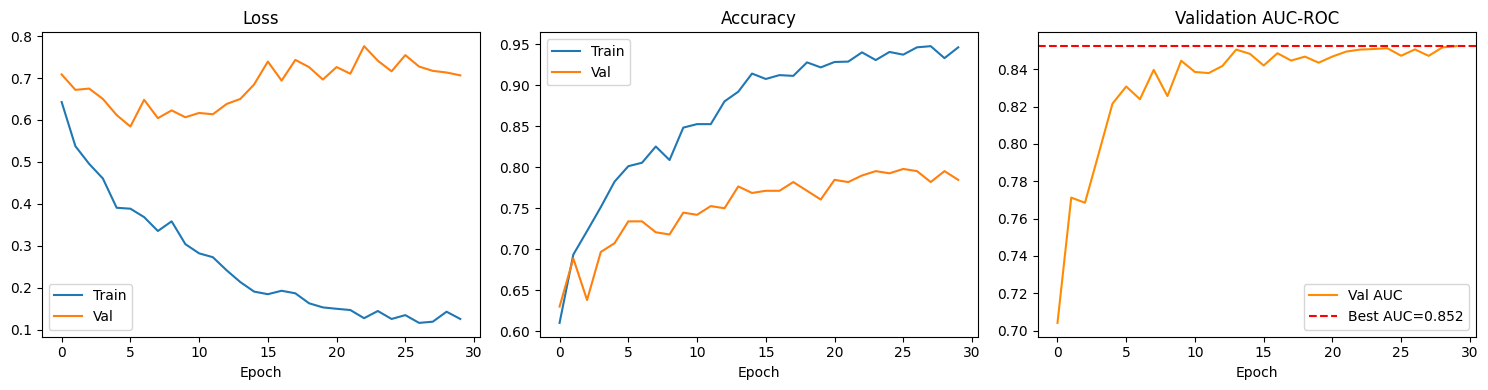

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['val_auc'], color='darkorange', label='Val AUC')
axes[2].axhline(best_val_auc, color='red', linestyle='--', label=f'Best AUC={best_val_auc:.3f}')
axes[2].set_title('Validation AUC-ROC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
plt.show()


## 10. Test Set Evaluation

In [16]:
# Load best checkpoint
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model.pth', map_location=device))
model.eval()

all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs.to(device))
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

print("=== Test Set Classification Report ===")
print(classification_report(all_labels, all_preds, target_names=['Low Pollution', 'High Pollution']))
print(f"AUC-ROC: {roc_auc_score(all_labels, all_probs):.4f}")


=== Test Set Classification Report ===
                precision    recall  f1-score   support

 Low Pollution       0.88      0.81      0.84       303
High Pollution       0.64      0.76      0.70       140

      accuracy                           0.79       443
     macro avg       0.76      0.78      0.77       443
  weighted avg       0.81      0.79      0.80       443

AUC-ROC: 0.8660


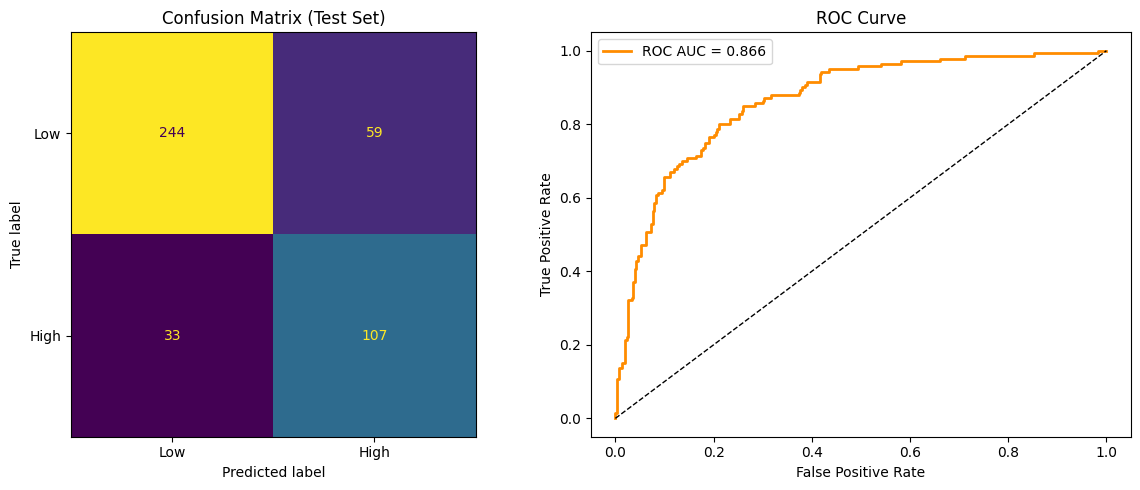

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['Low', 'High']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix (Test Set)')

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc = roc_auc_score(all_labels, all_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_evaluation.png', dpi=150)
plt.show()


## 11. Grad-CAM Interpretability

In [18]:
if GRADCAM_AVAILABLE:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image

    target_layer = model.layer4[-1]   # Last residual block of ResNet
    cam = GradCAM(model=model, target_layers=[target_layer])

    # Pick a few test samples
    sample_idx = np.random.choice(len(test_ds), min(4, len(test_ds)), replace=False)
    fig, axes = plt.subplots(len(sample_idx), 2, figsize=(8, len(sample_idx)*3))

    for row_i, idx in enumerate(sample_idx):
        img_t, label = test_ds[idx]
        img_np = img_t.permute(1,2,0).numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
        if img_np.shape[-1] == 1:
            img_np = np.repeat(img_np, 3, axis=-1)
        elif img_np.shape[-1] > 3:
            img_np = img_np[:,:,:3]

        grayscale_cam = cam(input_tensor=img_t.unsqueeze(0).to(device))
        cam_image = show_cam_on_image(img_np.astype(np.float32), grayscale_cam[0], use_rgb=True)

        axes[row_i, 0].imshow(img_np); axes[row_i, 0].set_title(f"Original | Label: {label.item()}")
        axes[row_i, 1].imshow(cam_image); axes[row_i, 1].set_title("Grad-CAM Activation")
        for ax in axes[row_i]: ax.axis('off')

    plt.suptitle("Grad-CAM: Which Pixels Drive the Prediction?", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'gradcam_visualization.png', dpi=150)
    plt.show()
else:
    print("Install pytorch-grad-cam to enable Grad-CAM visualization:")
    print("  pip install grad-cam")


Install pytorch-grad-cam to enable Grad-CAM visualization:
  pip install grad-cam


## 12. Next Steps

- **Increase input bands**: Use all 7 Landsat bands (including thermal TIRS band 10/11) for richer features.
- **Higher-res NAIP input**: Use 1m NAIP images with data augmentation to exploit spatial structure.
- **k-Fold Cross-Validation**: Use `StratifiedKFold` with the splits defined above for more robust AUC estimates.
- **Threshold tuning**: Adjust the decision threshold based on the ROC curve to optimise precision/recall trade-off.
- **Feed into Task 3 (Regression)**: Use the CNN embeddings extracted here as features for continuous emissions prediction.
